In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Tomato_dataset',
 'Tomato_dataset_split',
 'Classroom',
 'LAB-1.gdoc',
 'LAB-2.gdoc',
 'LAB-6 (1).gdoc',
 'LAB-6.gdoc',
 'LAB-7 (1).gdoc',
 'LAB-7.gdoc',
 'LAB-5.gdoc',
 'INFP Personality (Mediator) _ 16Personalities.pdf',
 'Untitled document (1).gdoc',
 'LAB-8.gdoc',
 'CSAI-E_70_HA2_SRM1.docx',
 'EduPlusCampus.pdf',
 'LAB-9 (1).gdoc',
 'LAB-9.gdoc',
 'LAB-12.gdoc',
 'python.pdf',
 'robo.pdf',
 'data.pdf',
 'LAB-13.gdoc',
 'LAB-10.gdoc',
 'LAB-14 (1).gdoc',
 'LAB-10 - final.gdoc',
 'LAB-14.gdoc',
 'Google Earth',
 'Defaulters Form_Module 1_Sem2_2024-25 (1) (2).pdf',
 'LAB_ASSIGNMENT[1].docx',
 'LAB_ASSIGNMENT[1] (1).pdf',
 'LAB_ASSIGNMENT[1].pdf',
 'Defaulters Form_Module 1_Sem2_2024-25 (1).gdoc',
 'Untitled document.gdoc',
 'Defaulters Form_Module 1_Sem2_2024-25 (1) (1).pdf',
 'Defaulters Form_Module 1_Sem2_2024-25 (1).pdf',
 'Heart_Disease_ML_Study_Revised.gdoc',
 'FF_180.docx',
 'ff180_review (2).docx',
 'ff180_review (1).docx',
 'ff180_review.docx',
 'IMG_2025

In [ ]:
dataset_path = "/content/drive/MyDrive/Tomato_dataset"

os.listdir(dataset_path)

['Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Target_Spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Late_blight',
 'Tomato___Early_blight',
 'Tomato___Bacterial_spot',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Leaf_Mold']

In [ ]:
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(folder, len(os.listdir(folder_path)))

Tomato___Tomato_Yellow_Leaf_Curl_Virus 4286
Tomato___Target_Spot 1123
Tomato___Tomato_mosaic_virus 299
Tomato___healthy 1273
Tomato___Spider_mites Two-spotted_spider_mite 1341
Tomato___Late_blight 1527
Tomato___Early_blight 800
Tomato___Bacterial_spot 1702
Tomato___Septoria_leaf_spot 1417
Tomato___Leaf_Mold 761


In [ ]:
import os
import pandas as pd

class_names = []
image_counts = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        class_names.append(folder)
        image_counts.append(len(os.listdir(folder_path)))

df = pd.DataFrame({
    "Disease": class_names,
    "Images": image_counts
})

df

,Disease,Images
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286
1,Tomato___Target_Spot,1123
2,Tomato___Tomato_mosaic_virus,299
3,Tomato___healthy,1273
4,Tomato___Spider_mites Two-spotted_spider_mite,1341
5,Tomato___Late_blight,1527
6,Tomato___Early_blight,800
7,Tomato___Bacterial_spot,1702
8,Tomato___Septoria_leaf_spot,1417
9,Tomato___Leaf_Mold,761


In [ ]:
print("Number of Classes :", len(df))
print("Total Images :", df["Images"].sum())
print()
print(df.sort_values("Images", ascending=False))

Number of Classes : 10
Total Images : 14529

                                         Disease  Images
0         Tomato___Tomato_Yellow_Leaf_Curl_Virus    4286
7                        Tomato___Bacterial_spot    1702
5                           Tomato___Late_blight    1527
8                    Tomato___Septoria_leaf_spot    1417
4  Tomato___Spider_mites Two-spotted_spider_mite    1341
3                               Tomato___healthy    1273
1                           Tomato___Target_Spot    1123
6                          Tomato___Early_blight     800
9                             Tomato___Leaf_Mold     761
2                   Tomato___Tomato_mosaic_virus     299


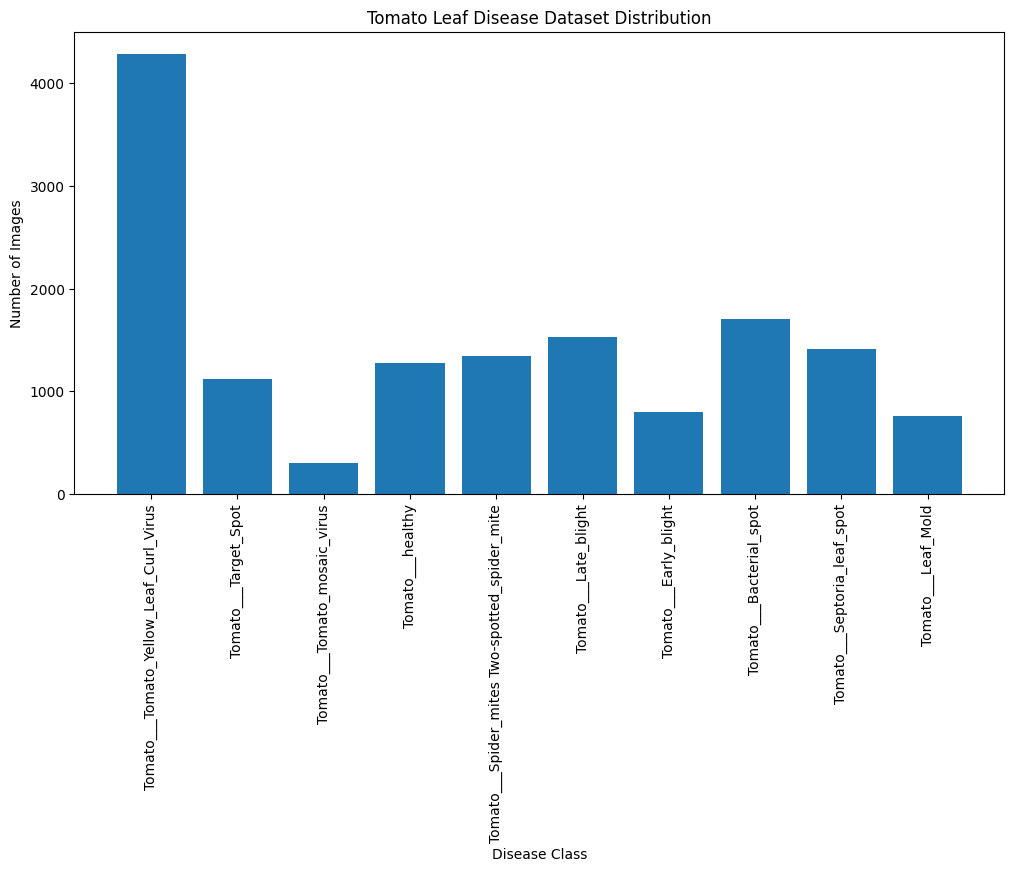

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(df["Disease"], df["Images"])

plt.xticks(rotation=90)

plt.xlabel("Disease Class")

plt.ylabel("Number of Images")

plt.title("Tomato Leaf Disease Dataset Distribution")

plt.show()

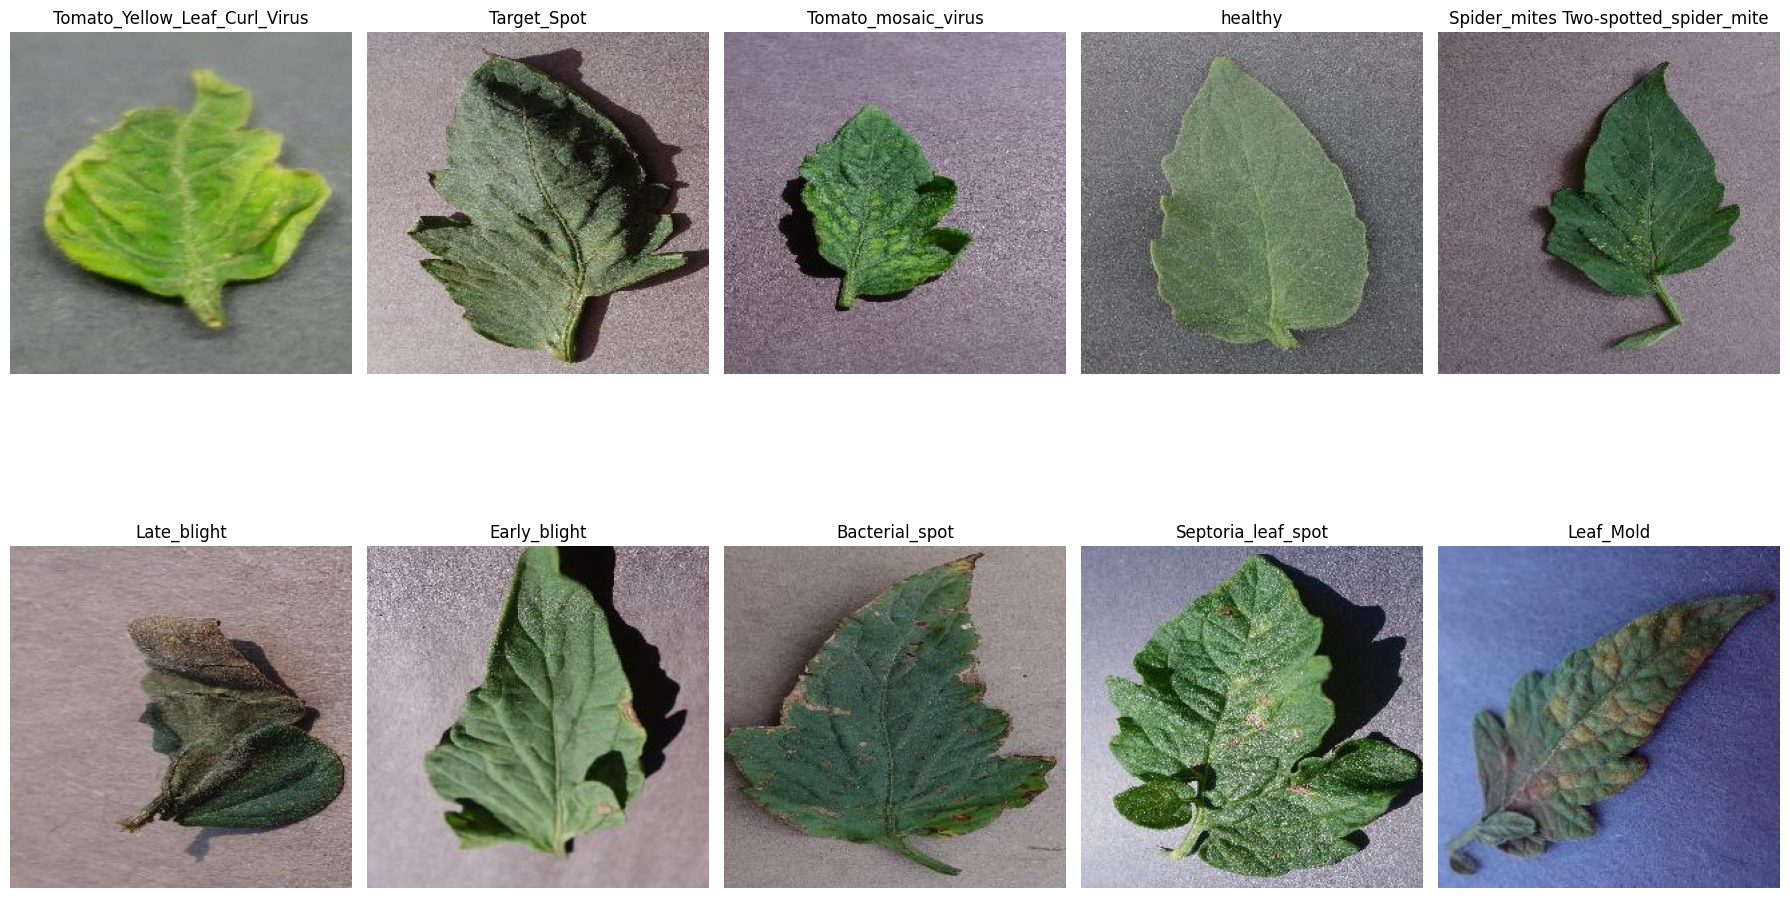

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(18,12))

for i, folder in enumerate(os.listdir(dataset_path)):

    folder_path = os.path.join(dataset_path, folder)

    image_name = random.choice(os.listdir(folder_path))

    image_path = os.path.join(folder_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title(folder.replace("Tomato___",""))

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

In [ ]:
input_folder = "/content/drive/MyDrive/Tomato_dataset"

output_folder = "/content/drive/MyDrive/Tomato_dataset_split"

In [ ]:
splitfolders.ratio(
    input=input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.70, 0.15, 0.15)
)

Copying files: 14529 files [07:50, 30.85 files/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = "/content/drive/MyDrive/Tomato_dataset_split/train"
val_dir = "/content/drive/MyDrive/Tomato_dataset_split/val"
test_dir = "/content/drive/MyDrive/Tomato_dataset_split/test"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

Found 10166 images belonging to 10 classes.


In [ ]:
validation_generator = val_datagen.flow_from_directory(
    val_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

Found 2175 images belonging to 10 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

Found 2188 images belonging to 10 classes.


In [ ]:
print(train_generator.class_indices)

{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


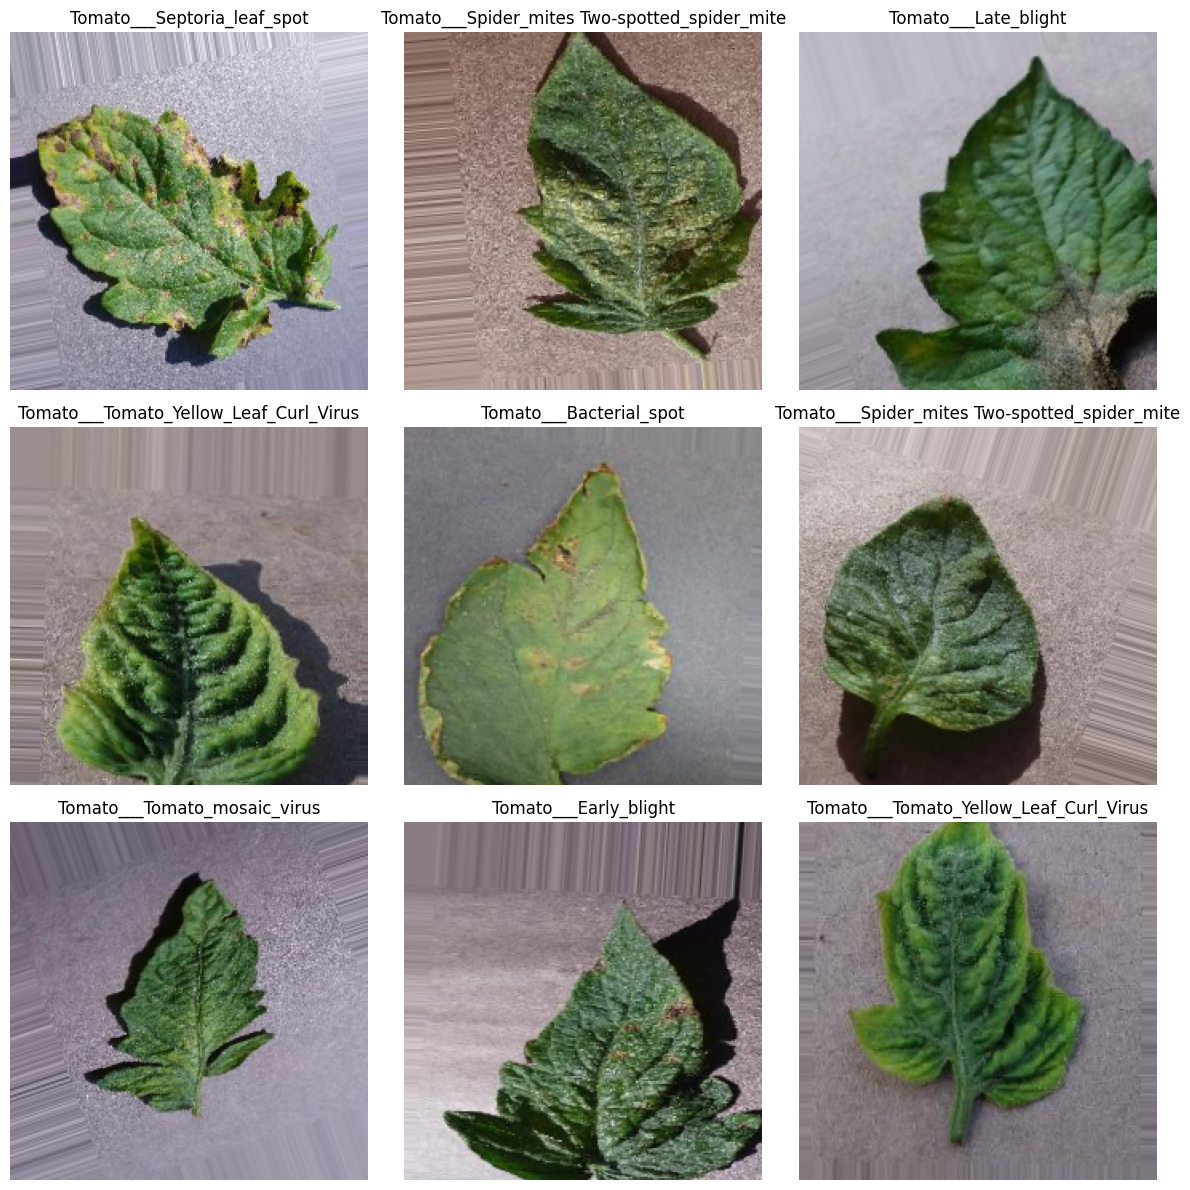

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[labels[i].argmax()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(224,224,3)
))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 4
model.add(Conv2D(
    filters=256,
    kernel_size=(3,3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Another Dense Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,194 (73.99 MB)

 Trainable params: 19,397,194 (73.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Tomato_Project/tomato_cnn_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Created directory: /content/drive/MyDrive/Tomato_Project


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.3501 - loss: 1.8755
Epoch 1: val_accuracy improved from None to 0.52598, saving model to /content/drive/MyDrive/Tomato_Project/tomato_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tomato_Project/tomato_cnn_best.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 192s 567ms/step - accuracy: 0.4220 - loss: 1.6661 - val_accuracy: 0.5260 - val_loss: 1.3019
Epoch 2/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.5609 - loss: 1.2602
Epoch 2: val_accuracy improved from 0.52598 to 0.66575, saving model to /content/drive/MyDrive/Tomato_Project/tomato_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tomato_Project/tomato_cnn_best.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 166s 520ms/step - accuracy: 0.6001 - loss: 1.1550 - val_accuracy: 0.6657 - val_loss: 1.0305
Epoch 3/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.6896 - loss: 0.8947
Epoch 3: val_accuracy improved from 0.66575

# ==========================================================
# POST-TRAINING MODEL EVALUATION & INFERENCE PIPELINE
# ==========================================================
In this section, we load the saved best model (`tomato_cnn_best.keras`), inspect its parameters, and perform comprehensive evaluation and single/batch leaf disease predictions.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras
from keras.models import load_model
from keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

# Load the trained best model
MODEL_PATH = "tomato_cnn_best.keras"
model = load_model(MODEL_PATH)
print("\nModel loaded successfully from:", MODEL_PATH)
model.summary()

### 1. Define Class Names and Index Mapping
The 10 tomato leaf disease categories mapped in alphabetical order:

In [ ]:
class_names = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

class_dict = {i: name for i, name in enumerate(class_names)}
print("Class Mapping:")
for k, v in class_dict.items():
    print(f"  [{k}] -> {v}")

### 2. Single Image Prediction & Probability Visualization Function
Function to load any leaf image, preprocess it, predict the disease, and plot class confidence distributions.

In [ ]:
def predict_and_visualize_leaf(img_path, model, class_names):
    """
    Predicts disease class for a tomato leaf image and visualizes prediction with probabilities.
    """
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_batch, verbose=0)[0]
    pred_idx = np.argmax(predictions)
    confidence = predictions[pred_idx] * 100
    predicted_label = class_names[pred_idx].replace("Tomato___", "").replace("_", " ")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Image
    ax1.imshow(img)
    ax1.set_title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%", fontsize=12, color="darkgreen", fontweight="bold")
    ax1.axis("off")

    # Subplot 2: Probabilities Bar Chart
    short_labels = [c.replace("Tomato___", "").replace("_", " ") for c in class_names]
    y_pos = np.arange(len(short_labels))
    colors = ["green" if i == pred_idx else "skyblue" for i in range(len(short_labels))]

    ax2.barh(y_pos, predictions * 100, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(short_labels, fontsize=9)
    ax2.invert_yaxis()  # top-down
    ax2.set_xlabel("Confidence (%)")
    ax2.set_title("Class Probability Distribution")
    ax2.set_xlim(0, 100)

    plt.tight_layout()
    plt.show()
    return predicted_label, confidence

print("Prediction helper function defined successfully!")

### 3. Model Evaluation on Test Set (Confusion Matrix & Classification Report)
Evaluates model performance across all test samples.

In [ ]:
def evaluate_model_on_test_set(model, test_generator):
    """
    Evaluates the model on test generator and plots confusion matrix and metrics.
    """
    test_steps = len(test_generator)
    test_generator.reset()
    
    print("Evaluating model on test set...")
    loss, acc = model.evaluate(test_generator, steps=test_steps, verbose=1)
    print(f"\nTest Accuracy: {acc*100:.2f}%")
    print(f"Test Loss: {loss:.4f}")

    # Generate predictions
    test_generator.reset()
    y_pred_probs = model.predict(test_generator, steps=test_steps, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes

    labels = list(test_generator.class_indices.keys())
    short_labels = [l.replace("Tomato___", "").replace("_", " ") for l in labels]

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=short_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short_labels, yticklabels=short_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Tomato Leaf Disease CNN")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("Evaluation helper function ready.")